In [2]:
import pandas as pd
import re
import math
from collections import Counter, defaultdict

splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
df_train = pd.read_parquet("hf://datasets/mteb/banking77/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/mteb/banking77/" + splits["test"])

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

Train shape: (9993, 3)
Test shape: (3076, 3)


In [3]:
def lemmatize(word):
    word = word.lower()
    
    # Irregular Words
    irregulars = {
        "spent": "spend", "withdrew": "withdraw", "withdrawn": "withdraw", "paid": "pay",
        "frozen": "freeze", "froze": "freeze", "lost": "lose", "stolen": "steal",
        "taken": "take", "took": "take", "held": "hold", "broken": "break",
        "swiped": "swipe", "dealt": "deal", "chosen": "choose", "bought": "buy",
        "sold": "sell", "sent": "send", "lent": "lend", "borrowed": "borrow",
        "kept": "keep", "found": "find", "spoken": "speak", "told": "tell",
        "meant": "mean", "understood": "understand", "thought": "think", 
        "caught": "catch", "fed": "feed", "written": "write",
        'am': 'be', 'is': 'be', 'are': 'be', 'was': 'be', 'were': 'be',
        'has': 'have', 'had': 'have',
        'does': 'do', 'did': 'do','goes': 'go', 'went': 'go',
        'bought': 'buy', 'stolen': 'steal', 'lost': 'lose','declined':'decline',
        'charged': 'charge','activated': 'activate',

        "better": "good","best": "good","worse": "bad",
        "worst": "bad","more": "much","most": "much",
        "less": "little","least": "little","farther": "far","farthest": "far","further": "far",
        "furthest": "far", "earlier": "early",
        "earliest": "early","later": "late","latest": "late",
        "costlier": "costly","costliest": "costly","easier": "easy",
        "easiest": "easy","busier": "busy","busiest": "busy",
        "trustier": "trusty", "trustiest": "trusty",
        "speedier": "speedy","speediest": "speedy"
        }
    
    if word in irregulars:
        return irregulars[word]
    
    # - Plurals
    if word.endswith('ies') and len(word) > 4:
        return word[:-3] + 'y'
    elif word.endswith('es') and (word.endswith('ses') or word.endswith('xes') or word.endswith('zes') or word.endswith('ches') or word.endswith('shes')):
        return word[:-2]
    elif word.endswith('s') and len(word) > 3 and not word.endswith('ss'):
        return word[:-1]
    
    # -ing (Present Participle)
    if word.endswith('ing') and len(word) > 5:
        return word[:-3]
    
    # -ed (Past Tense)
    if word.endswith('ed') and len(word) > 4:
        return word[:-2]

    # -est (Adjectives)
    if word.endswith("est"):
        return word[:-3]

    # -er Adjectives
    if word.endswith("er"):
        return word[:-2]
    # -ly Adverbs
    if word.endswith("ly"):
        return word[:-2]
    
    return word

In [4]:
#Lemmatization + N-Grams
def preprocess_advanced(text, use_bigrams=True):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    raw_tokens = text.split()
    
    # Apply Lemmatization
    tokens = [lemmatize(t) for t in raw_tokens]
    
    features = list(tokens)
    
    # Apply Bigrams
    if use_bigrams:
        for i in range(len(tokens) - 1):
            bigram = f"{tokens[i]}_{tokens[i+1]}"
            features.append(bigram)
            
    return features

train_data = [(preprocess_advanced(row['text']), row['label']) for _, row in df_train.iterrows()]
test_data = [(preprocess_advanced(row['text']), row['label']) for _, row in df_test.iterrows()]

print("Sample processed text:", train_data[0][0])

Sample processed text: ['i', 'be', 'still', 'wait', 'on', 'my', 'card', 'i_be', 'be_still', 'still_wait', 'wait_on', 'on_my', 'my_card']


In [5]:
# Calculate IDF (Inverse Document Frequency)
print("Calculating IDF weights...")
num_documents = len(train_data)
idf_dict = defaultdict(float)   # Storing idf score of each word
doc_freq = Counter()    # Counting the frequency of documents with the word

# Count documents containing each word
for tokens, _ in train_data:
    unique_words = set(tokens)
    for word in unique_words:
        doc_freq[word] += 1
        
# Compute IDF scores
for word, count in doc_freq.items():
    idf_dict[word] = math.log(num_documents / float(count))

print(f"Computed IDF for {len(idf_dict)} unique features (unigrams + bigrams).")

Calculating IDF weights...
Computed IDF for 19685 unique features (unigrams + bigrams).


In [6]:
# Train Naive Bayes with TF-IDF
vocabulary = set()
word_weights = defaultdict(lambda: defaultdict(float)) # Store TF-IDF sum instead of raw counts
class_totals = Counter() # Total TF-IDF weight per class
class_docs = Counter()  # Count of documents per class

print("Training Naive Bayes Model with TF-IDF...")
for tokens, label in train_data:
    class_docs[label] += 1
    
    # Calculate TF for this specific document
    tf_dict = Counter(tokens)   # Count of words in the document
    doc_len = len(tokens)
    
    for word, count in tf_dict.items():
        tf = count / float(doc_len)
        idf = idf_dict.get(word, 0)
        tfidf_score = tf * idf
        
        # Accumulate the continuous TF-IDF weight
        word_weights[label][word] += tfidf_score
        class_totals[label] += tfidf_score
        vocabulary.add(word)

vocab_size = len(vocabulary)
total_docs = len(train_data)

print(f"Training complete. Final Vocabulary Size: {vocab_size}")

Training Naive Bayes Model with TF-IDF...
Training complete. Final Vocabulary Size: 19685


In [7]:
# Prediction Logic
def predict(tokens, class_docs, word_weights, class_totals, vocab_size, total_docs):
    best_class = -1
    max_score = -float('inf')
    
    # Calculate TF-IDF for the query tokens to match training methodology
    tf_dict = Counter(tokens)
    doc_len = len(tokens)
    query_tfidf = {}
    for word, count in tf_dict.items():
        tf = count / float(doc_len)
        idf = idf_dict.get(word, 0)
        query_tfidf[word] = tf * idf
        
    for label in class_docs:
        log_prior = math.log(class_docs[label] / total_docs)
        log_likelihood = 0
        
        for word, query_weight in query_tfidf.items():
            if word in vocabulary:
                # Laplacian Smoothing with continuous weights
                numerator = word_weights[label][word] + 0.5
                denominator = class_totals[label] + 0.5*vocab_size
                # We multiply the log probability by the query word's importance (TF-IDF)
                log_likelihood += query_weight * math.log(numerator / denominator)
                
        total_score = log_prior + log_likelihood
        
        if total_score > max_score:
            max_score = total_score
            best_class = label
            
    return best_class

In [8]:
# 7. Evaluation
y_true = [row['label'] for _, row in df_test.iterrows()]
y_pred = []

for tokens, label in test_data:
    prediction = predict(tokens, class_docs, word_weights, class_totals, vocab_size, total_docs)
    y_pred.append(prediction)

correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
accuracy = (correct / len(y_true)) * 100
print(f"Accuracy (Lemmatization + Bigrams + TF-IDF): {accuracy:.2f}%")

Accuracy (Lemmatization + Bigrams + TF-IDF): 82.96%


In [9]:
import random
from sklearn.metrics import accuracy_score, classification_report

n = random.randint(0, len(test_data)-1)
predicted = predict(test_data[n][0],class_docs,word_weights,class_totals,vocab_size,total_docs)
print("Predicted = ",predicted,"Actual = ",test_data[n][1])

# --- Multi-class Evaluation Metrics ---
y_true = []
y_pred = []

print("\nEvaluating on entire test set... (this might take a few moments)")
for text, true_label in test_data:
    pred_label = predict(text, class_docs, word_weights, class_totals, vocab_size, total_docs)
    y_true.append(true_label)
    y_pred.append(pred_label)

accuracy = accuracy_score(y_true, y_pred)
print(f"\nOverall Accuracy: {accuracy:.4f}")

print("\nClassification Report (Precision, Recall, F1-Score):")
# Zero_division=0 to suppress warnings for labels that might not be predicted
print(classification_report(y_true, y_pred, zero_division=0))


Predicted =  37 Actual =  37

Evaluating on entire test set... (this might take a few moments)

Overall Accuracy: 0.8296

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.81      0.95      0.87        40
           1       1.00      1.00      1.00        40
           2       0.91      1.00      0.95        40
           3       0.86      0.77      0.81        39
           4       0.95      0.95      0.95        40
           5       0.74      0.78      0.76        40
           6       0.70      0.97      0.81        40
           7       0.76      0.95      0.84        40
           8       0.89      0.97      0.93        40
           9       0.89      0.97      0.93        40
          10       1.00      0.47      0.64        40
          11       0.80      0.82      0.81        40
          12       0.94      0.78      0.85        40
          13       0.76      0.97      0.86        40
          14  

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(144,144))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=.5)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

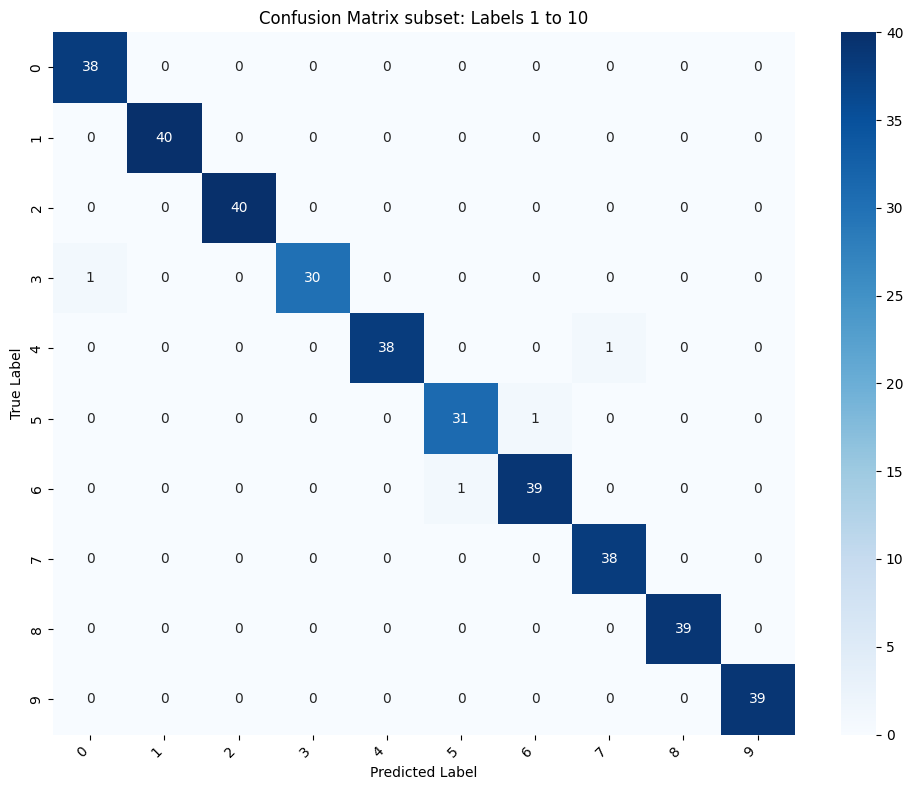

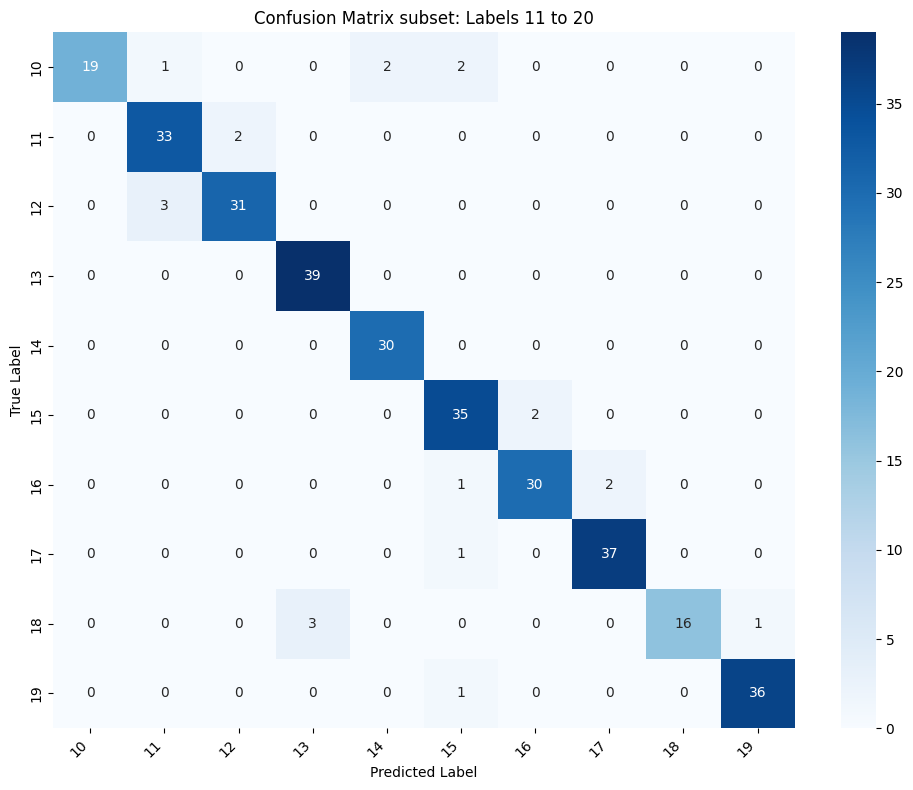

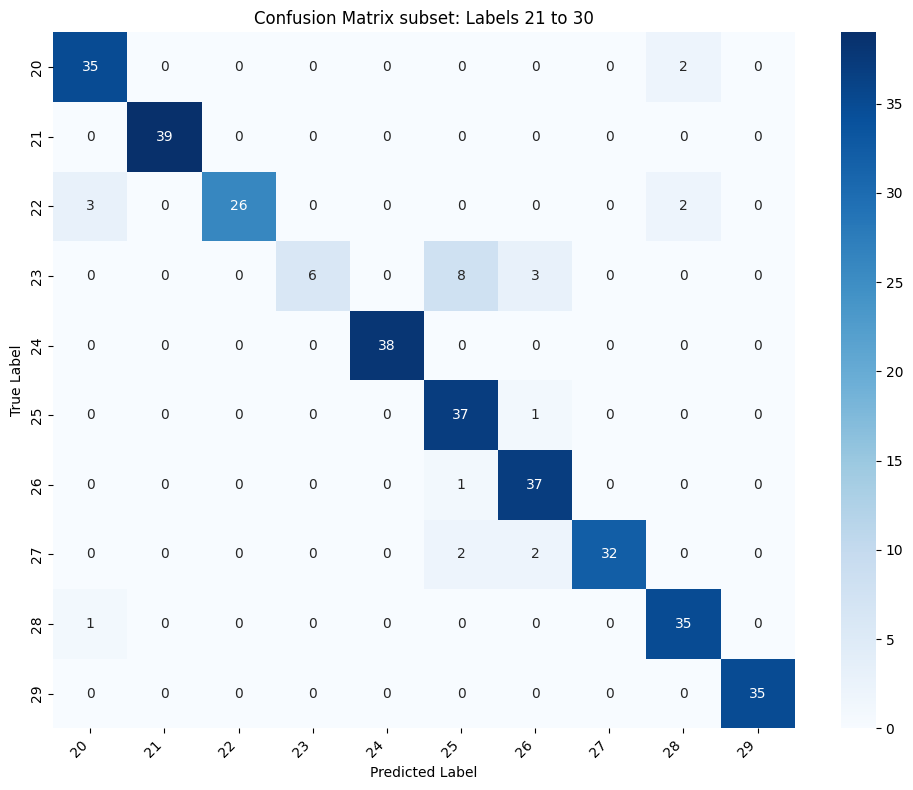

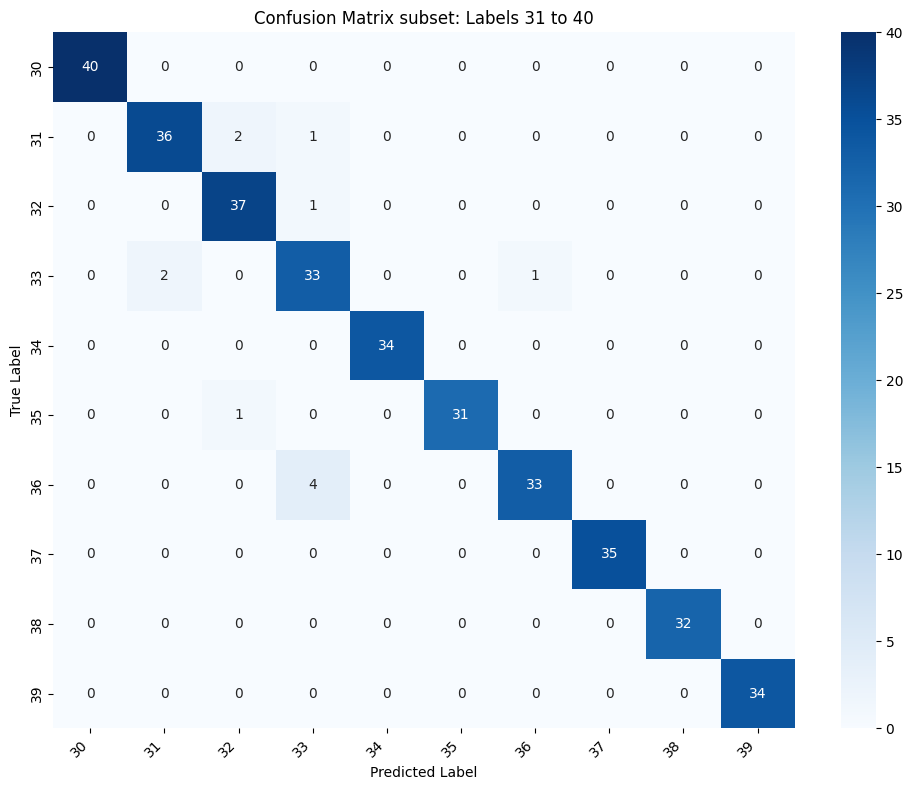

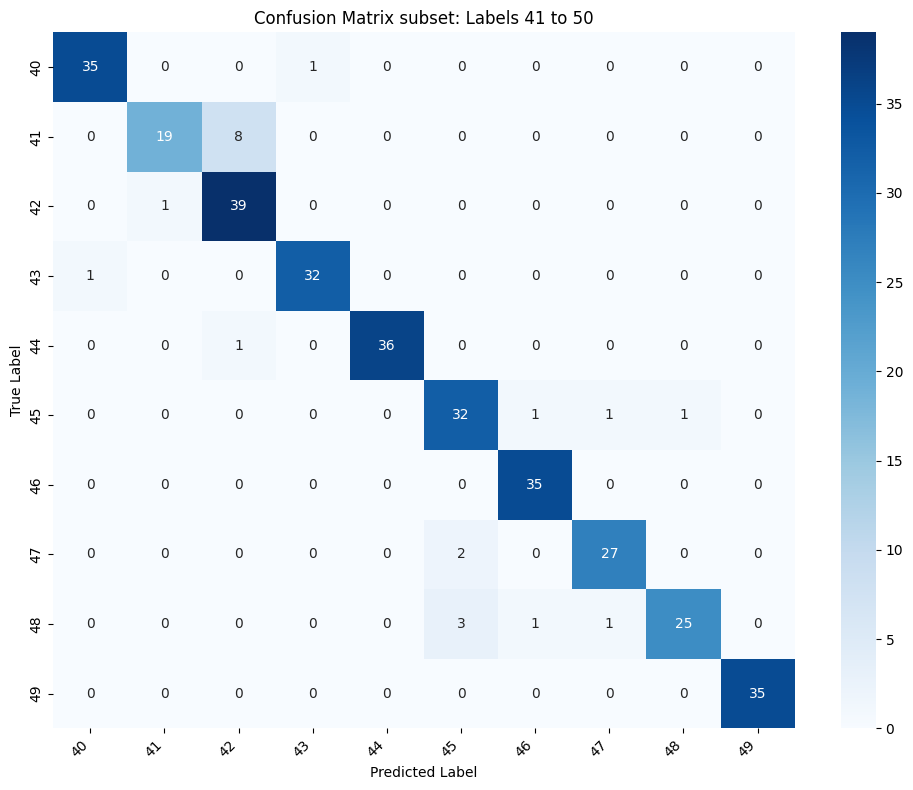

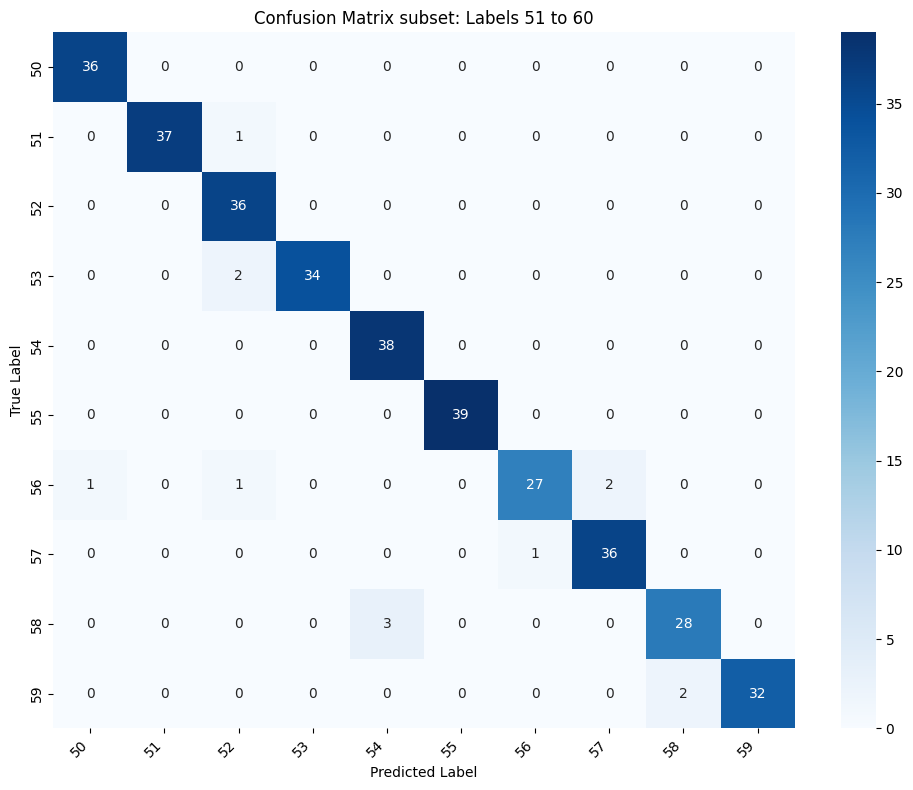

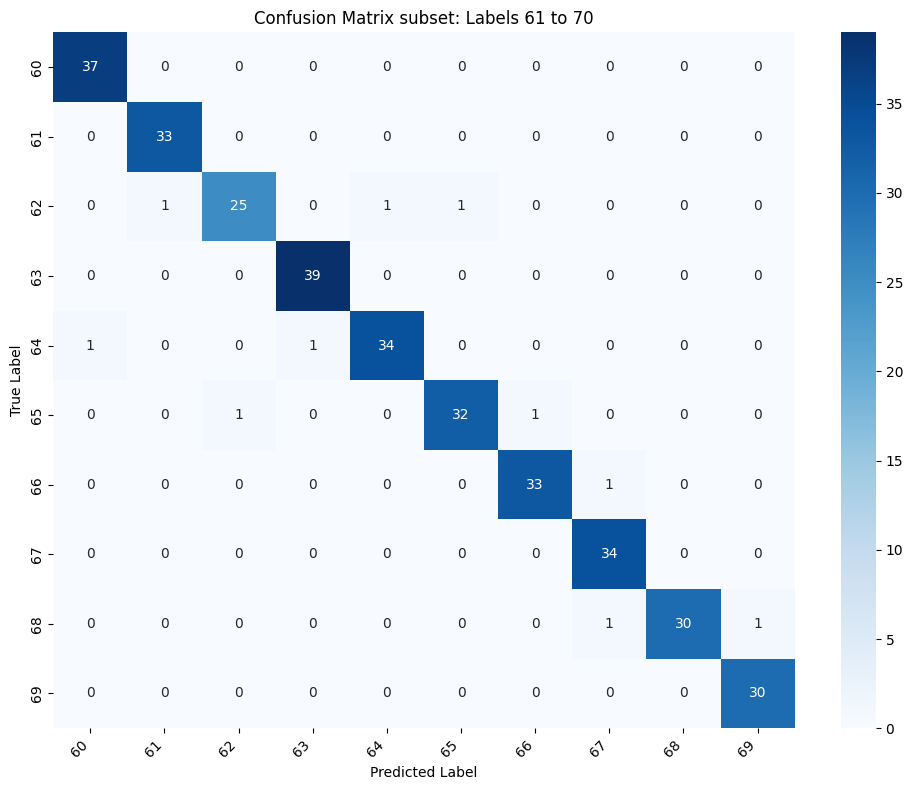

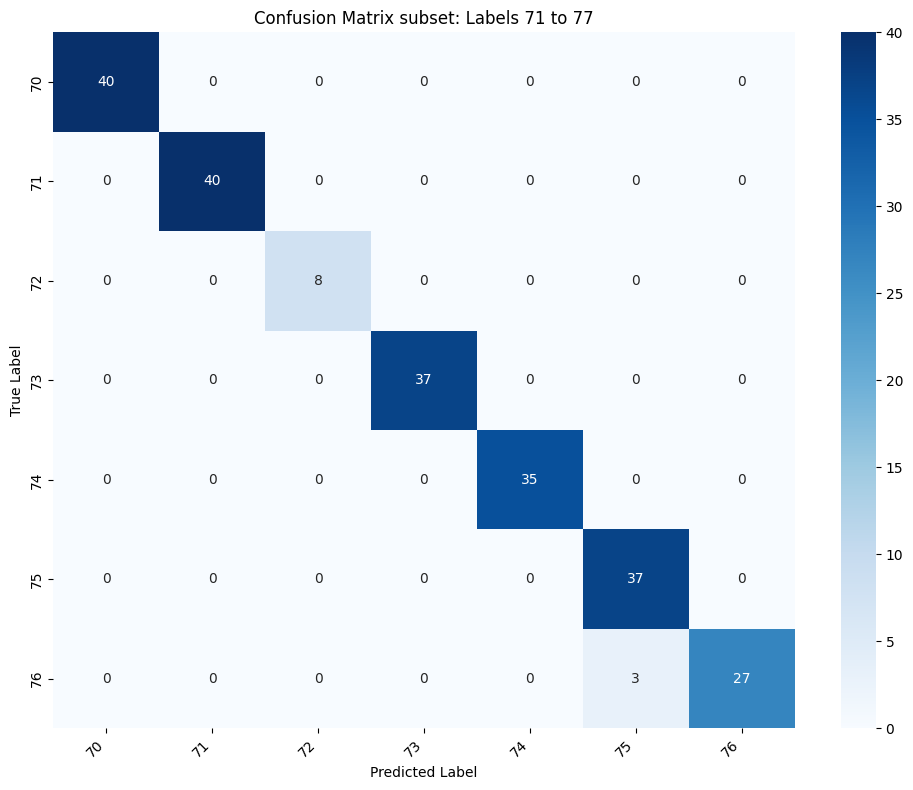

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Get all unique classes sorted
unique_classes = sorted(list(set(y_true)))

# Plot confusion matrix in chunks of 10 labels
chunk_size = 10
num_chunks = int(np.ceil(len(unique_classes) / chunk_size))

# Calculate the full confusion matrix first
full_cm = confusion_matrix(y_true, y_pred, labels=unique_classes)

for i in range(num_chunks):
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(unique_classes))
    current_classes = unique_classes[start_idx:end_idx]
    
    # Extract the square subset of the confusion matrix for these 10 classes
    sub_cm = full_cm[start_idx:end_idx, start_idx:end_idx]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(sub_cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=current_classes, yticklabels=current_classes)
    plt.title(f'Confusion Matrix subset: Labels {start_idx+1} to {end_idx}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
